In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
import numpy as np
import os 
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

%matplotlib inline

In [2]:
# 1. Credenciales de la Base de Datos LOCAL
DB_USER = "postgres"  # Usuario por defecto de PG
DB_PASS = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "myvolt_local"

# 2. Codificar la contraseña
DB_PASS_ENCODED = quote_plus(DB_PASS)

# 3. Crear la cadena de conexión
# NOTA: Quitamos '?sslmode=require' porque en local usualmente no se usa SSL
try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(connection_string)
    
    # 4. Prueba de conexión
    with engine.connect() as conn:
        print("¡Conexión a PostgreSQL LOCAL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a la BD Local: {e}")
    print("Consejo: Verifica que tu contraseña sea correcta y que PostgreSQL esté corriendo en el puerto 5432.")

¡Conexión a PostgreSQL LOCAL exitosa!


In [19]:
#query = """
#SELECT time, power_w
#FROM consumption_data
#WHERE id_device = (
#    SELECT id_device 
#    FROM devices 
#    WHERE mac_address = 'B0:A7:32:34:54:9C'
#)
#ORDER BY time DESC
#LIMIT 2500; 
#"""

#df = pd.read_sql_query(query, con=engine)
#print(f"Se cargaron {len(df)} registros (los más recientes) desde la base de datos.")
#df.head()

# Opción A: Traer TODO lo que haya (útil si solo tienes datos de prueba)
query = """
SELECT time, power_w
FROM consumption_data
ORDER BY time DESC
LIMIT 5000; 
"""

df = pd.read_sql_query(query, con=engine)
print(f"Se cargaron {len(df)} registros.")
df.head()

Se cargaron 5000 registros.


,time,power_w
0,2025-11-24 22:41:15.468 -0600,34.01
1,2025-11-24 22:41:14.558 -0600,34.01
2,2025-11-24 22:41:13.445 -0600,27.21
3,2025-11-24 22:41:12.447 -0600,34.01
4,2025-11-24 22:41:11.592 -0600,34.01


In [20]:
# 1. Seleccionamos solo la columna de potencia
datos_para_modelo = df[['power_w']]

# 2. Creamos y entrenamos el escalador
scaler = MinMaxScaler()
datos_escalados = scaler.fit_transform(datos_para_modelo)

print("Datos reales escalados (0 a 1):")
print(datos_escalados[:5])

Datos reales escalados (0 a 1):
[[0.83317001]
 [0.83317001]
 [0.66658501]
 [0.83317001]
 [0.83317001]]


In [13]:
# Arquitectura del Autoencoder
input_layer = Input(shape=(1,))
encoder = Dense(8, activation='relu')(input_layer)
encoder = Dense(4, activation='relu')(encoder) # Cuello de botella
decoder = Dense(8, activation='relu')(encoder)
decoder = Dense(1, activation='sigmoid')(decoder) 

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
historial = autoencoder.fit(
    datos_escalados, 
    datos_escalados, 
    epochs=5, 
    batch_size=32,
    shuffle=True,
    validation_split=0.1 
)
print("Modelo entrenado con datos reales")

Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0042 - val_loss: 0.0204 - val_mae: 0.0204
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0042 - val_loss: 0.0199 - val_mae: 0.0199
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0041 - mae: 0.0041 - val_loss: 0.0195 - val_mae: 0.0195
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0042 - val_loss: 0.0192 - val_mae: 0.0192
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038 - mae: 0.0038 - val_loss: 0.0188 - val_mae: 0.0188
Modelo entrenado con datos reales


In [24]:
# 1. Reconstruir los datos
datos_reconstruidos = autoencoder.predict(datos_escalados)
errores = mean_absolute_error(datos_escalados.T, datos_reconstruidos.T, multioutput='raw_values')
df['error_nn'] = errores

# 2. Definir umbral (98% de confianza)
umbral = np.percentile(df['error_nn'], 80)

# 3. Calcular "precisión"
final_error = historial.history['val_loss'][-1]
print(f"Error Final: {final_error:.6f}")
print(f"Precisión de Reconstrucción: {(1 - final_error) * 100:.2f}%")
print(f"Umbral de Anomalía Real: {umbral}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step
Error Final: 0.018818
Precisión de Reconstrucción: 98.12%
Umbral de Anomalía Real: 0.01235284935683012


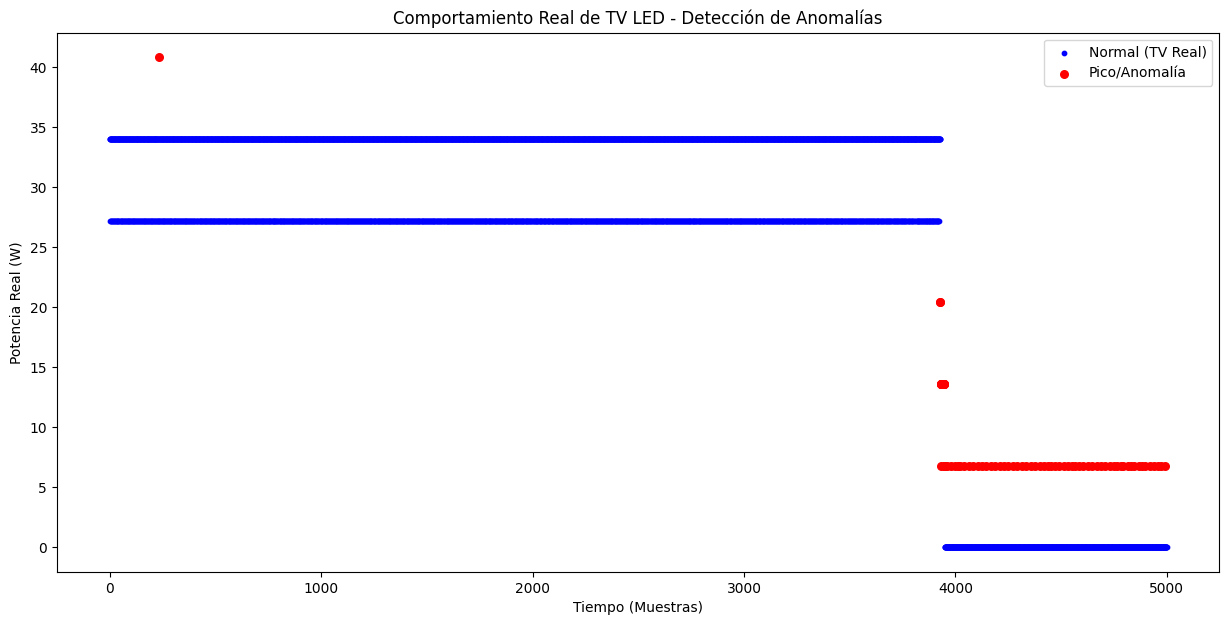

In [25]:
df['anomalia_nn'] = df['error_nn'] > umbral
df_normal = df[df['anomalia_nn'] == False]
df_anomalo = df[df['anomalia_nn'] == True]

plt.figure(figsize=(15, 7))
plt.scatter(df_normal.index, df_normal['power_w'], c='blue', label='Normal (TV Real)', s=10)
plt.scatter(df_anomalo.index, df_anomalo['power_w'], c='red', label='Pico/Anomalía', s=30)

plt.title('Comportamiento Real de TV LED - Detección de Anomalías')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Potencia Real (W)')
plt.legend()
plt.show()

In [23]:
# Rutas
ruta_modelo_nn = '../neural_network/RN_DT_tv_led_real_autoencoder_v1.h5'
ruta_scaler_nn = '../scaler/DT_tv_led_real_scaler_v1.pkl'

# Crear carpetas si no existen
os.makedirs(os.path.dirname(ruta_modelo_nn), exist_ok=True)
os.makedirs(os.path.dirname(ruta_scaler_nn), exist_ok=True)

# Guardar
autoencoder.save(ruta_modelo_nn)
joblib.dump(scaler, ruta_scaler_nn)

print(f"¡Modelo REAL guardado en: {ruta_modelo_nn}!")

¡Modelo REAL guardado en: ../neural_network/RN_DT_tv_led_real_autoencoder_v1.h5!


In [25]:
import os
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. ASEGURAR QUE TENEMOS LOS ERRORES
# Si por alguna razón 'error_nn' no existe, lo calculamos aquí mismo
if 'error_nn' not in df.columns:
    print("Calculando errores de reconstrucción...")
    datos_reconstruidos = autoencoder.predict(datos_escalados)
    errores = mean_absolute_error(datos_escalados.T, datos_reconstruidos.T, multioutput='raw_values')
    df['error_nn'] = errores

# 2. Calcular el Umbral
umbral = np.percentile(df['error_nn'], 98)
print(f"Umbral calculado: {umbral}")

# 3. Guardar el Umbral en un archivo
ruta_archivo = '../umbral/tv_led_threshold.txt'

# Crear carpeta si no existe
os.makedirs(os.path.dirname(ruta_archivo), exist_ok=True)

with open(ruta_archivo, 'w') as f:
    f.write(str(umbral))

print(f"¡Umbral guardado exitosamente en: {ruta_archivo}!")

Umbral calculado: 0.01871786104401653
¡Umbral guardado exitosamente en: ../umbral/tv_led_threshold.txt!
